In [ ]:
!pip install pot

# Model-Aligned Coupling Tutorial

This tutorial walks through the two-dimensional toy example behind **Beyond Optimal Transport: Model-Aligned Coupling for Flow Matching**. The goal is to illustrate how different coupling choices affect one-step generation, from random couplings and OT couplings to Model-Aligned Coupling (MAC).

## Abstract

Flow Matching (FM) is an effective framework for training a model to learn a vector field that transports samples from a source distribution to a target distribution. To train the model, early FM methods use random couplings, which often result in crossing paths and lead the model to learn non-straight trajectories that require many integration steps to generate high-quality samples. To address this, recent methods adopt Optimal Transport (OT) to construct couplings by minimizing geometric distances, which helps reduce path crossings. However, we observe that such geometry-based couplings do not necessarily align with the model's preferred trajectories, making it difficult to learn the vector field induced by these couplings, which prevents the model from learning straight trajectories. Motivated by this, we propose Model-Aligned Coupling (MAC), an effective method that matches training couplings based not only on geometric distance but also on alignment with the model's preferred transport directions based on its prediction error. To avoid the time-costly match process, MAC proposes to select the top-$k$ fraction of couplings with the lowest error for training. Extensive experiments show that MAC significantly improves generation quality and efficiency in few-step settings compared to existing methods.



## Toy Setup

The source distribution $p_0$ is a four-component Gaussian mixture on the left, and the target distribution $p_1$ is a two-component Gaussian mixture on the right. In Flow Matching, training supervision is defined by paired samples $(x_0, x_1)$, which determine the target vector field for transporting $x_0$ to $x_1$.



In [1]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import ot
import scipy.optimize
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

BATCH_SIZE = 1024
NUM_EPOCHS = 2000
LR = 5e-3
NUM_SAMPLES = 500
NUM_STEPS = 1
SEED = 2026

START_COLOR = "blue"
TARGET_COLOR = "red"
GENERATED_COLOR = "green"
PATH_COLOR = "gray"

Using device: mps


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [3]:
def sample_source_4mog(batch_size, mean_sign=-1):
    """Source distribution p0: four Gaussian components with unequal weights."""
    mu = 8.0
    means = torch.tensor(
        [
            [mean_sign * mu, -3 * mu],
            [mean_sign * mu, -mu],
            [mean_sign * mu, mu],
            [mean_sign * mu, 3 * mu],
        ],
        dtype=torch.float32,
    )
    probs = torch.tensor([0.28, 0.24, 0.24, 0.24])
    indices = torch.multinomial(probs, batch_size, replacement=True)
    return (means[indices] + torch.randn(batch_size, 2)).to(DEVICE)


def sample_target_2mog(batch_size, mean_sign=1):
    """Target distribution p1: two Gaussian components with unequal weights."""
    mu = 8.0
    means = torch.tensor(
        [[mean_sign * mu, -mu], [mean_sign * mu, mu]],
        dtype=torch.float32,
    )
    probs = torch.tensor([0.45, 0.55])
    indices = torch.multinomial(probs, batch_size, replacement=True)
    return (means[indices] + torch.randn(batch_size, 2)).to(DEVICE)


def interpolate(x0, x1, t):
    return (1 - t.unsqueeze(-1)) * x0 + t.unsqueeze(-1) * x1


def interpolate_multi(x0, x1, t):
    return (1 - t) * x0 + t * x1

## Flow Matching Objective

For a coupling pair $(x_0, x_1)$, the linear interpolation path is

$$
x_t = (1 - t)x_0 + t x_1, \quad t \sim \mathcal{U}[0,1].
$$

The vector field $v_\theta(x_t, t)$ is trained to predict the path velocity:

$$
\mathcal{L}_{\mathrm{FM}} = \mathbb{E}_{t, (x_0, x_1)} \left[\left\|v_\theta(x_t, t) - (x_1 - x_0)\right\|^2\right].
$$

Changing the coupling changes the target vector field, even when $p_0$ and $p_1$ stay fixed.



In [4]:
class VectorField(nn.Module):
    """2D vector field v_theta(x, t)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
        )

    def forward(self, t, x):
        return self.net(torch.cat([x, t.unsqueeze(-1)], dim=-1))


class ShortcutVectorField(nn.Module):
    """2D vector field v_theta(x, t, d) used by the shortcut baseline."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
        )

    def forward(self, t, x, d):
        return self.net(torch.cat([x, t.unsqueeze(-1), d.unsqueeze(-1)], dim=-1))

In [5]:
def update_ema_model(ema_model, model, momentum=0.99):
    for ema_param, param in zip(ema_model.parameters(), model.parameters()):
        ema_param.data.mul_(momentum).add_(param.data, alpha=1.0 - momentum)


def train_step_flow_matching(model, optimizer, x0, x1):
    batch_size = x0.shape[0]
    t = torch.rand(batch_size, device=DEVICE)
    xt = interpolate(x0, x1, t)
    target = x1 - x0
    pred = model(t, xt)
    loss = F.mse_loss(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss


def select_low_loss_indices(ema_model, x0, x1, percentile=0.4):
    batch_size = x0.shape[0]
    num_points = 2
    t_grid = torch.linspace(0, 1, num_points, device=DEVICE).unsqueeze(1).expand(-1, batch_size)
    xt = interpolate_multi(
        x0.unsqueeze(0).expand(num_points, -1, -1),
        x1.unsqueeze(0).expand(num_points, -1, -1),
        t_grid.unsqueeze(2),
    )
    target = (x1 - x0).unsqueeze(0).expand(num_points, -1, -1)
    pred = ema_model(t_grid.flatten(), xt.reshape(-1, 2)).reshape(num_points, batch_size, 2)
    loss = F.mse_loss(pred, target, reduction="none").mean(dim=2).mean(dim=0)
    k = int(batch_size * percentile)
    return torch.argsort(loss)[:k]



## Experiments

Run the cells below in order. Each visualization is displayed inline in the notebook. We now compare the couplings and one-step generation results on this toy experiment, starting from the default random coupling used in Flow Matching.



In [6]:
def train_random_flow_matching():
    model = VectorField().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    for epoch in range(NUM_EPOCHS):
        x0 = sample_source_4mog(BATCH_SIZE)
        x1 = sample_target_2mog(BATCH_SIZE)
        loss = train_step_flow_matching(model, optimizer, x0, x1)
        if epoch % 250 == 0:
            print(f"Random FM epoch {epoch:04d}: loss={loss.item():.4f}")
    return model


def train_ot_flow_matching():
    model = VectorField().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    for epoch in range(NUM_EPOCHS):
        x0 = sample_source_4mog(BATCH_SIZE)
        x1 = sample_target_2mog(BATCH_SIZE)
        cost = ot.dist(x0.detach().cpu().numpy(), x1.detach().cpu().numpy(), metric="euclidean") ** 2
        row_ind, col_ind = scipy.optimize.linear_sum_assignment(cost)
        row_ind = torch.as_tensor(row_ind, device=DEVICE)
        col_ind = torch.as_tensor(col_ind, device=DEVICE)
        x0_aligned = x0[row_ind]
        x1_aligned = x1[col_ind]
        loss = train_step_flow_matching(model, optimizer, x0_aligned, x1_aligned)
        if epoch == 0:
            plot_couplings(x0_aligned, x1_aligned, title="OT couplings")
        if epoch % 250 == 0:
            print(f"OT-FM epoch {epoch:04d}: loss={loss.item():.4f}")
    return model


def train_mac_flow_matching(momentum=0.99, warmup_epochs=2, percentile=0.4, visualize_epoch=None):
    model = VectorField().to(DEVICE)
    ema_model = VectorField().to(DEVICE)
    ema_model.load_state_dict(model.state_dict())
    ema_model.requires_grad_(False)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    if visualize_epoch is None:
        visualize_epoch = NUM_EPOCHS - 1

    for epoch in range(NUM_EPOCHS):
        x0 = sample_source_4mog(BATCH_SIZE)
        x1 = sample_target_2mog(BATCH_SIZE)
        if epoch < warmup_epochs:
            loss = train_step_flow_matching(model, optimizer, x0, x1)
            ema_model.load_state_dict(model.state_dict())
        else:
            with torch.no_grad():
                indices = select_low_loss_indices(ema_model, x0, x1, percentile=percentile)
                if epoch == visualize_epoch:
                    plot_couplings(x0[indices], x1[indices], title="MAC constructed couplings")
            loss = train_step_flow_matching(model, optimizer, x0[indices], x1[indices])
            update_ema_model(ema_model, model, momentum)
        if epoch % 250 == 0:
            print(f"MAC-FM epoch {epoch:04d}: loss={loss.item():.4f}")
    return model




In [7]:
def shortcut_step(model, ema_model, optimizer, x0, x1, denoise_timesteps=128, bootstrap_every=8):
    batch_size = x0.shape[0]
    bootstrap_size = batch_size // bootstrap_every
    flow_size = batch_size - bootstrap_size

    log2_sections = int(math.log2(denoise_timesteps))
    dt_base = torch.repeat_interleave(
        log2_sections - 1 - torch.arange(log2_sections),
        bootstrap_size // log2_sections,
    ).to(DEVICE)
    dt_base = torch.cat([
        dt_base,
        torch.zeros(bootstrap_size - dt_base.shape[0], device=DEVICE),
    ]).to(DEVICE)
    dt_bootstrap_base = dt_base + 1
    dt_sections = 2 ** dt_base
    dt = 1.0 / dt_sections.float()
    dt_bootstrap = dt / 2

    k = (torch.rand_like(dt_sections, dtype=torch.float) * dt_sections.float()).floor().long()
    t_b = k.float() / dt_sections

    x0_b = x0[:bootstrap_size]
    x1_b = x1[:bootstrap_size]
    x_b = interpolate(x0_b, x1_b, t_b)
    with torch.no_grad():
        v1 = ema_model(t_b, x_b, dt_bootstrap_base.float())
        x_b2 = x_b + dt_bootstrap.unsqueeze(-1) * v1
        v2 = ema_model(t_b + dt_bootstrap, x_b2, dt_bootstrap_base.float())
    bst_v = (v1 + v2) / 2

    x0_f = x0[:flow_size]
    x1_f = x1[:flow_size]
    t_f = torch.randint(0, denoise_timesteps, (flow_size,), device=DEVICE).float() / denoise_timesteps
    x_f = interpolate(x0_f, x1_f, t_f)
    v_f = x1_f - x0_f

    dt_flow = int(math.log2(denoise_timesteps))
    d_f = torch.ones(batch_size, dtype=torch.int32, device=DEVICE) * dt_flow

    x_train = torch.cat([x_b, x_f], dim=0)
    t_train = torch.cat([t_b, t_f], dim=0)
    d_train = torch.cat([dt_base, d_f[:flow_size]], dim=0)
    v_train = torch.cat([bst_v, v_f], dim=0)

    pred = model(t_train, x_train, d_train)
    loss = F.mse_loss(pred, v_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss


def train_shortcut(momentum=0.99):
    model = ShortcutVectorField().to(DEVICE)
    ema_model = ShortcutVectorField().to(DEVICE)
    ema_model.load_state_dict(model.state_dict())
    for param in ema_model.parameters():
        param.requires_grad = False
    ema_model.eval()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    for epoch in range(NUM_EPOCHS):
        x0 = sample_source_4mog(BATCH_SIZE)
        x1 = sample_target_2mog(BATCH_SIZE)
        loss = shortcut_step(model, ema_model, optimizer, x0, x1)
        if epoch == 0:
            ema_model.load_state_dict(model.state_dict())
        update_ema_model(ema_model, model, momentum)
        if epoch % 250 == 0:
            print(f"Shortcut epoch {epoch:04d}: loss={loss.item():.4f}")
    return model














In [8]:
def plot_couplings(x0, x1, title=None, annotate=False):
    x0_np = x0.detach().cpu().numpy()
    x1_np = x1.detach().cpu().numpy()
    t_vals = np.linspace(0, 1, 50)

    plt.figure(figsize=(6, 6))
    for i in range(x0_np.shape[0]):
        path = np.array([(1 - t) * x0_np[i] + t * x1_np[i] for t in t_vals])
        plt.plot(path[:, 0], path[:, 1], color=PATH_COLOR, alpha=0.3, linestyle="dotted")

    plt.scatter(x0_np[:, 0], x0_np[:, 1], color=START_COLOR, label="Start ($p_0$)", alpha=0.8, s=30)
    plt.scatter(x1_np[:, 0], x1_np[:, 1], color=TARGET_COLOR, label="End ($p_1$)", alpha=0.8, s=30)

    if annotate:
        source_means = np.array([[-8.0, -24.0], [-8.0, -8.0], [-8.0, 8.0], [-8.0, 24.0]])
        source_probs = [0.28, 0.24, 0.24, 0.24]
        target_means = np.array([[8.0, -8.0], [8.0, 8.0]])
        target_probs = [0.45, 0.55]
        for i, (mu, pi) in enumerate(zip(source_means, source_probs), 1):
            plt.annotate(rf"$\mu_{{0,{i}}},\ \pi_{{0,{i}}}={pi:.2f}$", xy=mu, xytext=(mu[0] - 3, mu[1] + 3), fontsize=12, arrowprops=dict(arrowstyle="->", lw=1.5))
        for i, (mu, pi) in enumerate(zip(target_means, target_probs), 1):
            plt.annotate(rf"$\mu_{{1,{i}}},\ \pi_{{1,{i}}}={pi:.2f}$", xy=mu, xytext=(mu[0] + 3, mu[1] + 3), fontsize=12, arrowprops=dict(arrowstyle="->", lw=1.5))

    if title:
        plt.title(title)
    plt.legend(fontsize=12)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def rollout_fm(model, num_samples=NUM_SAMPLES, num_steps=NUM_STEPS):
    model.eval()
    x0 = sample_source_4mog(num_samples).detach().cpu().numpy()
    x1 = sample_target_2mog(num_samples).detach().cpu().numpy()
    trajectories = np.zeros((num_samples, num_steps + 1, 2))
    trajectories[:, 0] = x0
    x_t = torch.tensor(x0, device=DEVICE, dtype=torch.float32)
    for i, t in enumerate(np.linspace(0, 1, num_steps)):
        t_tensor = torch.full((num_samples,), t, device=DEVICE)
        with torch.no_grad():
            delta = model(t_tensor, x_t)
        x_t = x_t + delta * (1.0 / num_steps)
        trajectories[:, i + 1] = x_t.detach().cpu().numpy()
    return x0, x1, trajectories


def rollout_shortcut(model, num_samples=NUM_SAMPLES, num_steps=NUM_STEPS):
    model.eval()
    x0 = sample_source_4mog(num_samples).detach().cpu().numpy()
    x1 = sample_target_2mog(num_samples).detach().cpu().numpy()
    trajectories = np.zeros((num_samples, num_steps + 1, 2))
    trajectories[:, 0] = x0
    x_t = torch.tensor(x0, device=DEVICE, dtype=torch.float32)
    d = torch.full((num_samples,), math.log2(num_steps), device=DEVICE)
    for i, t in enumerate(np.linspace(0, 1, num_steps)):
        t_tensor = torch.full((num_samples,), t, device=DEVICE)
        with torch.no_grad():
            delta = model(t_tensor, x_t, d)
        x_t = x_t + delta * (1.0 / num_steps)
        trajectories[:, i + 1] = x_t.detach().cpu().numpy()
    return x0, x1, trajectories



def plot_generated_paths(x0, trajectories, title=None):
    final = trajectories[:, -1]
    plt.figure(figsize=(6, 6))
    for i in range(trajectories.shape[0]):
        plt.plot(trajectories[i, :, 0], trajectories[i, :, 1], color=PATH_COLOR, alpha=0.3, linestyle="dotted")
    plt.scatter(x0[:, 0], x0[:, 1], color=START_COLOR, label="Start ($p_0$)", alpha=0.8, s=30)
    plt.scatter(final[:, 0], final[:, 1], color=GENERATED_COLOR, label=r"Generated ($\hat{x}_1$)", alpha=0.8, s=30)
    if title:
        plt.title(title)
    plt.legend(fontsize=12)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



## Random Couplings

We first visualize the default random coupling used by vanilla Flow Matching. Samples from $p_0$ and $p_1$ are paired independently, which creates many crossing straight-line paths.


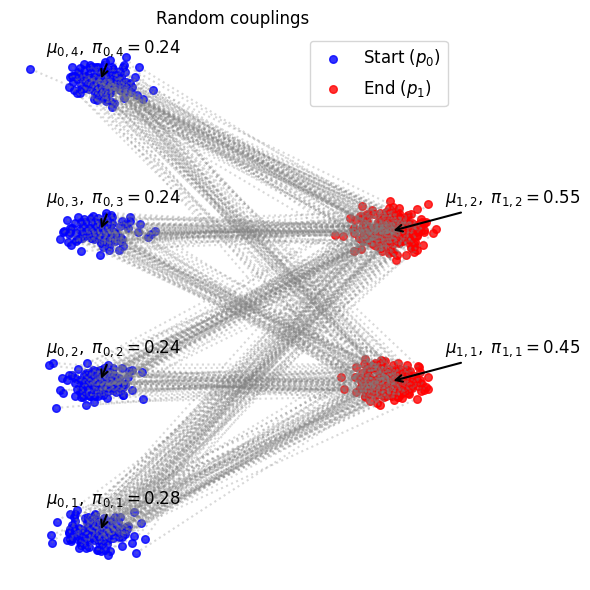

In [9]:
# Ground-truth random coupling panel.
set_seed(SEED)
x0_vis = sample_source_4mog(NUM_SAMPLES)
x1_vis = sample_target_2mog(NUM_SAMPLES)
plot_couplings(x0_vis, x1_vis, title="Random couplings", annotate=True)

The random coupling already shows the core difficulty: although each individual target path is straight, many paths cross each other, creating inconsistent training directions in the same region.


## Vanilla Flow Matching

Vanilla Flow Matching trains directly on these random pairs. A neural network predicts similar velocity vectors at nearby points in space and time, so when crossing paths provide sharply different directions at the same location, the learned vector field tends to regress toward their average. The following cell trains the vector field and then samples with a single Euler step from $t=0$ to $t=1$.


Random FM epoch 0000: loss=330.0583
Random FM epoch 0250: loss=58.8537
Random FM epoch 0500: loss=67.8328
Random FM epoch 0750: loss=61.7468
Random FM epoch 1000: loss=48.0856
Random FM epoch 1250: loss=53.7625
Random FM epoch 1500: loss=50.1482
Random FM epoch 1750: loss=41.3559


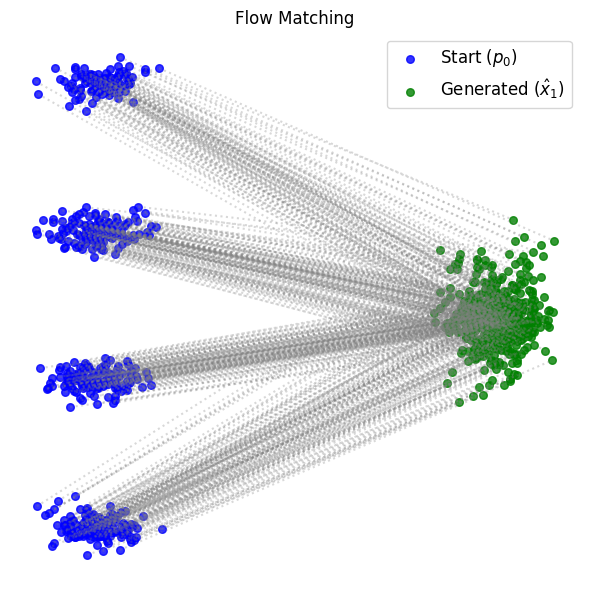

In [10]:
# Train and visualize Flow Matching with random couplings.
set_seed(SEED)
fm_model = train_random_flow_matching()
x0, x1, traj = rollout_fm(fm_model)
plot_generated_paths(x0, traj, title="Flow Matching")

The one-step generation quality is poor. The averaged vector field does not transport the four source modes cleanly into the two target modes.


## Optimal Transport Couplings

Existing work often uses Optimal Transport to address this problem. By explicitly reducing the total transport cost, OT-based couplings mitigate path crossings and provide more structured transport directions than random coupling.

However, relying only on geometric distance is still insufficient: a geometrically short coupling may still be misaligned with the model's preferred transport directions. First, when the source and target distributions are unbalanced, OT can still induce path crossings, especially near the source distribution, leading to different velocity directions at the same spatial location. Second, OT is typically solved within each mini-batch in practice, so it only gives a batch-local optimum. Across iterations, crossings and inconsistent velocity directions can still appear across batches. As a result, the model can still learn an averaged direction at these crossing regions.



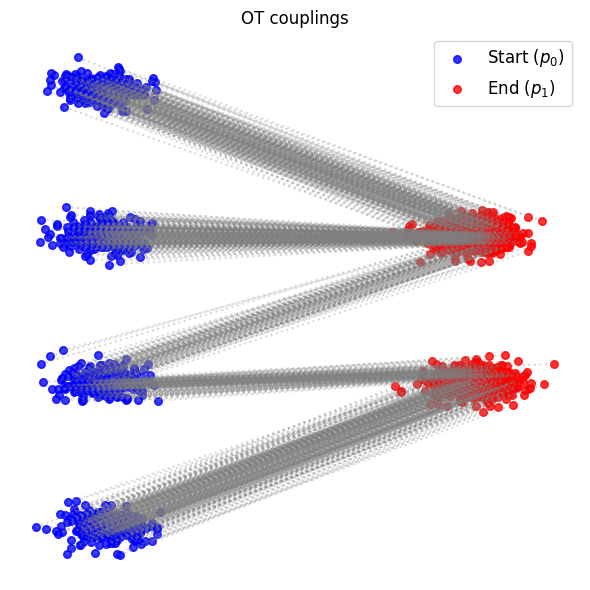

OT-FM epoch 0000: loss=200.8508
OT-FM epoch 0250: loss=0.7685
OT-FM epoch 0500: loss=1.1124
OT-FM epoch 0750: loss=0.3370
OT-FM epoch 1000: loss=0.8202
OT-FM epoch 1250: loss=0.4501
OT-FM epoch 1500: loss=0.7738
OT-FM epoch 1750: loss=0.5948


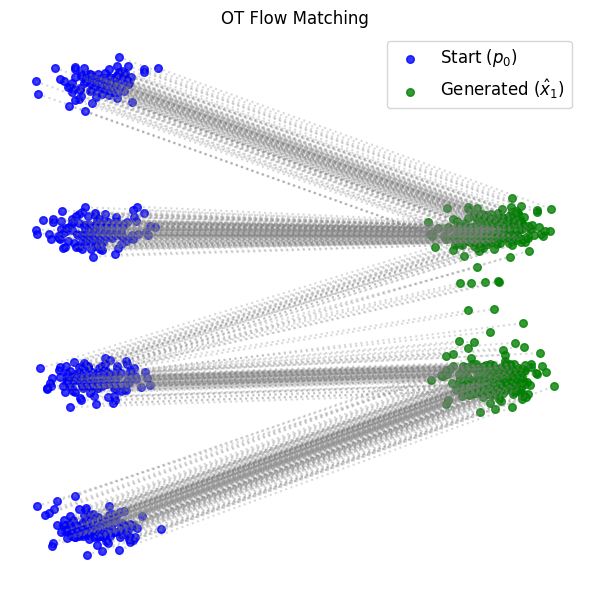

In [11]:
# Train and visualize Flow Matching with OT couplings.
set_seed(SEED)
ot_model = train_ot_flow_matching()
x0, x1, traj = rollout_fm(ot_model)
plot_generated_paths(x0, traj, title="OT Flow Matching")

The OT coupling reduces many crossings, but the one-step generation result is still imperfect. This matches the discussion above: when crossings and cross-batch inconsistencies remain, the model can still learn averaged directions rather than the desired transport field.


## Shortcut Baseline

Shortcut does not modify the coupling itself; instead, it improves few-step generation by conditioning the vector field on the desired discretization step and enforcing self-consistency across different step sizes. This directly targets fast sampling, so it is a relevant baseline for the one-step setting.


Shortcut epoch 0000: loss=282.2083
Shortcut epoch 0250: loss=50.1195
Shortcut epoch 0500: loss=44.0854
Shortcut epoch 0750: loss=43.0234
Shortcut epoch 1000: loss=41.9107
Shortcut epoch 1250: loss=43.2636
Shortcut epoch 1500: loss=42.9541
Shortcut epoch 1750: loss=39.1551


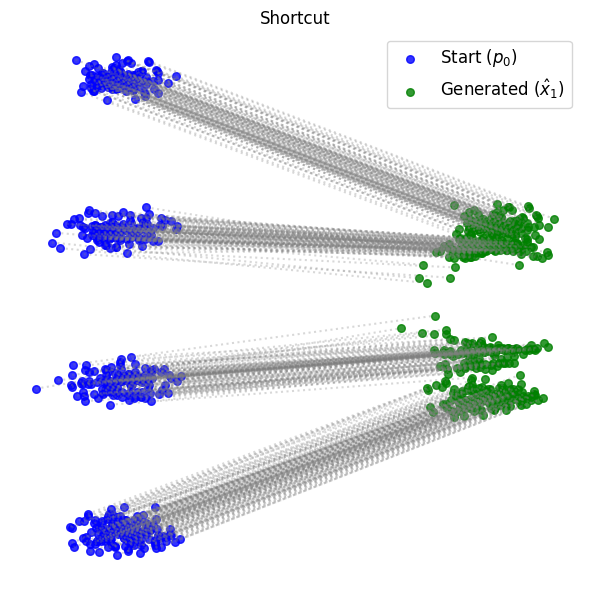

In [12]:
# Train and visualize Shortcut.
set_seed(SEED)
shortcut_model = train_shortcut()
x0, x1, traj = rollout_shortcut(shortcut_model)
plot_generated_paths(x0, traj, title="Shortcut")

Shortcut can improve few-step behavior, but it does not directly change the coupling selection rule. The training pairs can still be misaligned with the model's preferred transport directions.


## Model-Aligned Coupling

The results above suggest that improving the sampler alone is not enough when the training couplings remain misaligned. Our method changes the coupling criterion itself: instead of selecting pairs only by geometric distance, Model-Aligned Coupling (MAC) prefers pairs that the current model can predict well.

For each candidate pair, define the model-alignment error as

$$
\mathcal{L}_{\mathrm{pair}}(x_0, x_1) := \mathbb{E}_{t \sim \mathcal{U}[0,1]} \left[ \left\| v_\theta((1 - t)x_0 + t x_1, t) - (x_1 - x_0) \right\|^2 \right].
$$

The ideal MAC coupling minimizes this error over admissible couplings:

$$
\tilde{\rho} = \arg\min_{\rho \in \mathcal{C}(p_0, p_1)} \mathbb{E}_{(x_0, x_1) \sim \rho}\left[\mathcal{L}_{\mathrm{pair}}(x_0, x_1)\right].
$$

In this tutorial version, we use the practical selection strategy: keep the lowest-error fraction of pairs according to an EMA model and train on those model-aligned couplings.


MAC-FM epoch 0000: loss=326.0119
MAC-FM epoch 0250: loss=5.0062
MAC-FM epoch 0500: loss=4.9774
MAC-FM epoch 0750: loss=5.4733
MAC-FM epoch 1000: loss=3.4257
MAC-FM epoch 1250: loss=4.2656
MAC-FM epoch 1500: loss=3.8311
MAC-FM epoch 1750: loss=3.8930


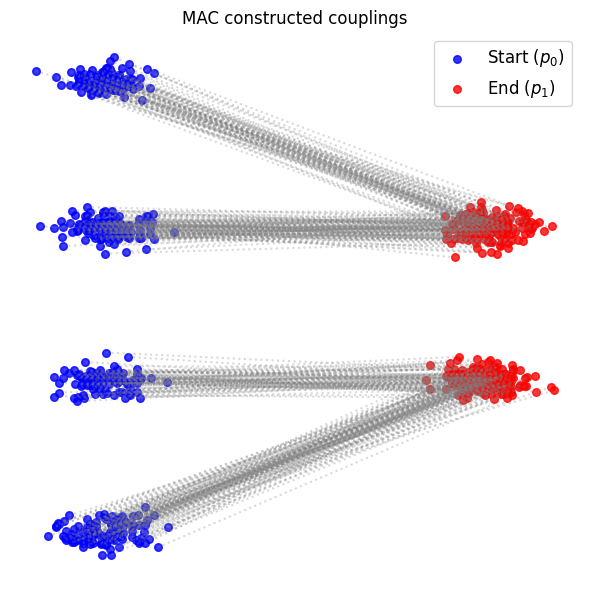

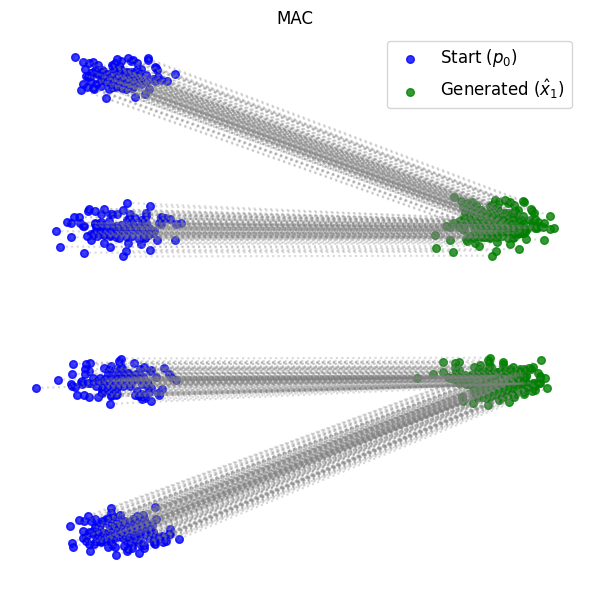

In [13]:
# Train and visualize MAC with Flow Matching.
set_seed(SEED)
mac_model = train_mac_flow_matching()
x0, x1, traj = rollout_fm(mac_model)
plot_generated_paths(x0, traj, title="MAC")

MAC with Flow Matching selects couplings that are easier for the current model to fit. In this toy example, the constructed couplings reduce conflicting directions and produce cleaner transport from the source modes to the target modes.
